<a href="https://colab.research.google.com/github/Tee-Sarun/DADS-6005-Real-Time-Analytics/blob/main/FB_Prophet_(HW5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install prophet
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import itertools
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import json
from prophet.serialize import model_to_json, model_from_json

In [5]:
# --- การโหลดและเตรียมข้อมูล (หน้า 3-5) ---
url = 'https://github.com/thanachart/ai-builders-tabular-data/raw/main/Data/bangkok-air-quality.csv'
# อ่านไฟล์โดยระบุ parse_dates เพื่อให้คอลัมน์ date เป็น datetime object
df = pd.read_csv(url, parse_dates=['date'])

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# แปลงค่า pm25 ให้เป็น numeric (หน้า 5)
df['pm25'] = pd.to_numeric(df['pm25'], errors='coerce')

# เลือกเฉพาะคอลัมน์ที่ต้องการและเปลี่ยนชื่อเป็น ds และ y ตามมาตรฐานของ Prophet (หน้า 5-6)
df_pm25 = df[['date', 'pm25']].rename(columns={'date': 'ds', 'pm25': 'y'})

In [6]:
# --- การสร้างและฝึกโมเดลพื้นฐาน (หน้า 6-8) ---
my_model = Prophet(interval_width=0.95)
my_model.fit(df_pm25)

# สร้าง Dataframe สำหรับอนาคต (พยากรณ์ล่วงหน้า 7 วัน)
future_dates = my_model.make_future_dataframe(periods=7)
forecast = my_model.predict(future_dates)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


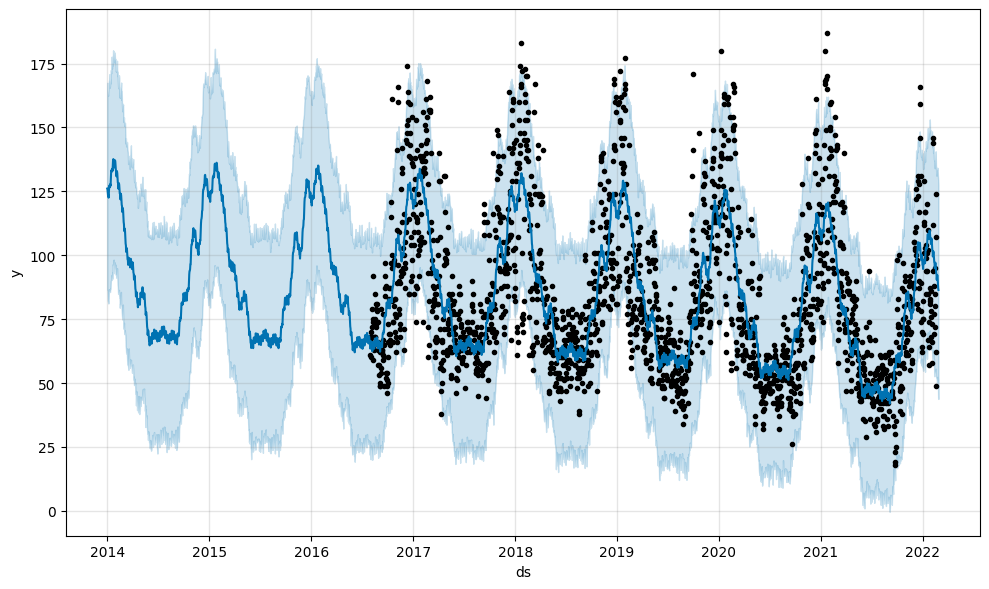

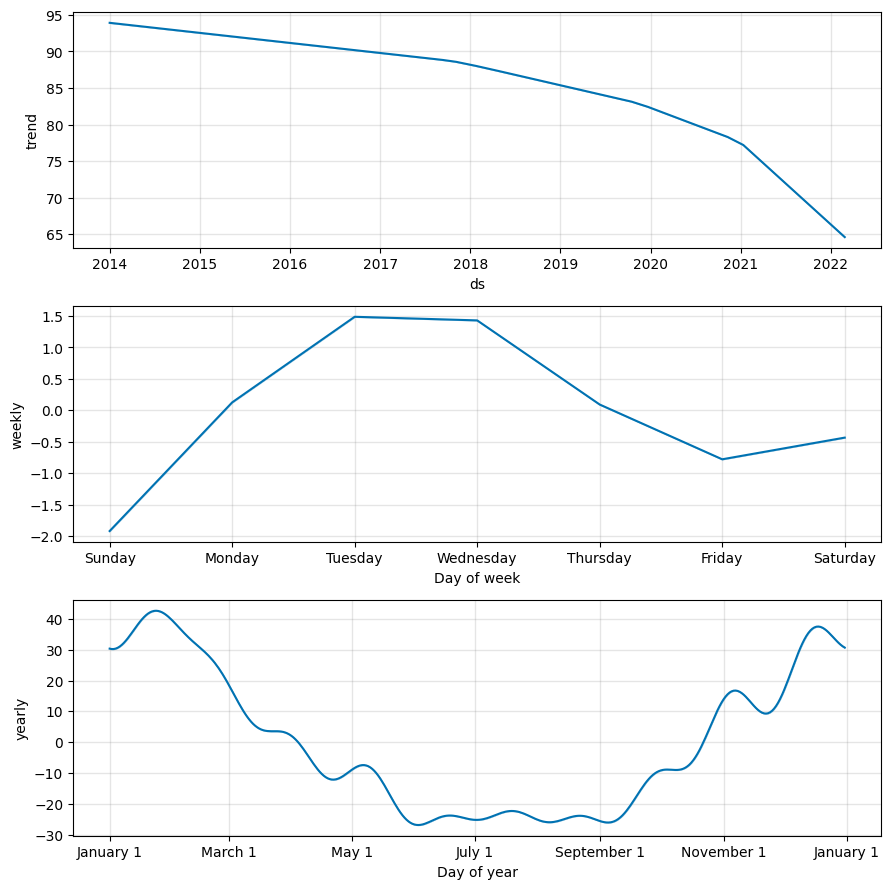

In [7]:
# แสดงผลการพยากรณ์และส่วนประกอบ (หน้า 8)
fig1 = my_model.plot(forecast)
fig2 = my_model.plot_components(forecast)
plt.show()

In [8]:
# --- การประเมินผลด้วย Cross Validation (หน้า 9-10) ---
df_cv = cross_validation(my_model, initial='1820 days', period='10 days', horizon='10 days')
df_p = performance_metrics(df_cv)
print(df_p.head())

INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


  0%|          | 0/21 [00:00<?, ?it/s]

  horizon         mse       rmse        mae      mape     mdape     smape  \
0  1 days  604.590282  24.588418  19.166522  0.362945  0.243609  0.266794   
1  2 days  603.956124  24.575519  19.550308  0.322362  0.317749  0.260611   
2  3 days  561.978322  23.706082  19.428842  0.389149  0.229071  0.283846   
3  4 days  400.489004  20.012221  14.775910  0.260246  0.159114  0.205055   
4  5 days  378.511502  19.455372  16.196555  0.258270  0.171349  0.218606   

   coverage  
0  0.857143  
1  0.904762  
2  0.857143  
3  0.904762  
4  1.000000  


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


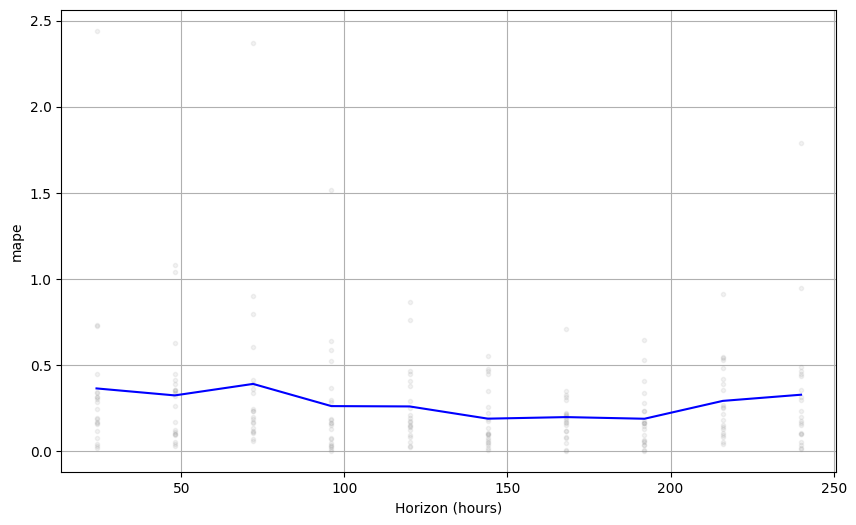

In [9]:
# พล็อตกราฟ MAPE (หน้า 10)
fig_cv = plot_cross_validation_metric(df_cv, metric='mape')
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


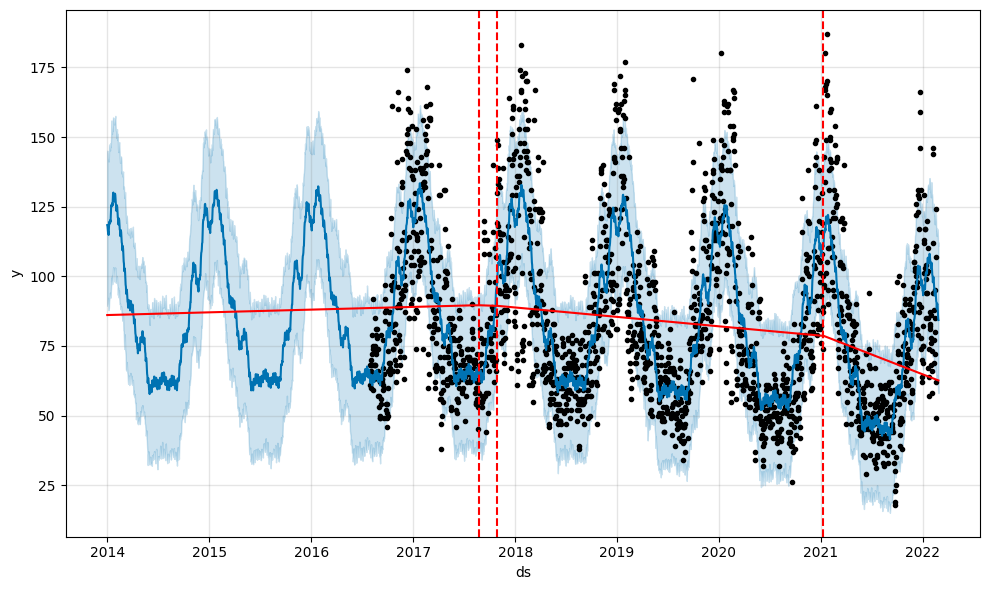

In [10]:
# --- การปรับแต่ง Parameter (Tuning) (หน้า 12-15) ---
# ตัวอย่างการปรับ changepoint_prior_scale เพื่อตรวจจับการเปลี่ยน Trend (หน้า 12)
my_model_trend = Prophet(changepoint_prior_scale=0.1)
my_model_trend.fit(df_pm25)
forecast_trend = my_model_trend.predict(future_dates)
fig_trend = my_model_trend.plot(forecast_trend)
a = add_changepoints_to_plot(fig_trend.gca(), my_model_trend, forecast_trend)

In [14]:
# ตัวอย่างการปรับ seasonality_prior_scale (หน้า 14-15)
my_model_seasonal = Prophet(seasonality_prior_scale=0.1)
my_model_seasonal.fit(df_pm25)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [12]:
# --- Hyperparameter Tuning Pipeline (หน้า 16) ---
param_grid = {
    'changepoint_prior_scale': [0.1, 1, 5],
    'seasonality_prior_scale': [0.1, 1, 5],
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
mape_scores = []

for params in all_params:
    m = Prophet(**params).fit(df_pm25)
    cv_results = cross_validation(m, initial='1820 days', period='10 days', horizon='10 days')
    p_metrics = performance_metrics(cv_results, rolling_window=1)
    mape_scores.append(p_metrics['mape'].values[0])

tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mape_scores
print(tuning_results)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


  0%|          | 0/21 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


  0%|          | 0/21 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


...

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


  0%|          | 0/21 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 21 forecasts with cutoffs between 2021-07-24 00:00:00 and 2022-02-09 00:00:00


  0%|          | 0/21 [00:00<?, ?it/s]

   changepoint_prior_scale  seasonality_prior_scale      mape
0                      0.1                      0.1  0.275885
1                      0.1                      1.0  0.275929
2                      0.1                      5.0  0.275856
3                      1.0                      0.1  0.264479
4                      1.0                      1.0  0.264564
5                      1.0                      5.0  0.264083
6                      5.0                      0.1  0.259014
7                      5.0                      1.0  0.260065
8                      5.0                      5.0  0.260477


In [13]:
# --- การบันทึกและโหลดโมเดล (หน้า 17) ---
with open('prophet_model.json', 'w') as fout:
    json.dump(model_to_json(my_model), fout)

with open('prophet_model.json', 'r') as fin:
    loaded_model = model_from_json(json.load(fin))

## แสดงค่าพารามิเตอร์ที่ดีที่สุด (Best Hyperparameters)

In [16]:
# หา combination ที่มีค่า MAPE น้อยที่สุด
best_params = tuning_results.loc[tuning_results['mape'].idxmin()]
print("Best hyperparameters combination:")
print(best_params)

Best hyperparameters combination:
changepoint_prior_scale    5.000000
seasonality_prior_scale    0.100000
mape                       0.259014
Name: 6, dtype: float64
